In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import umap

import pyLDAvis
import pyLDAvis.gensim_models as gensim_models

from gensim.models import LdaModel, CoherenceModel, LdaMulticore
from gensim.corpora import Dictionary

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.presidents.utils import concat_seq_by_class

init_notebook()

**Notes**
- `LdaMulticore` produces non-deterministic results due to parallelism (even with `random_state` set). Can switch to `LDAModel` but results are worse (in terms of pyLDAvis), many overlapping circles.
- Most likely, we will use LDA just as a visualization technique, not as an improvement to algorithms.

- Coherence score is kinda low ***(why?)*** -> visual inspection. The goal is to avoid many overlapping circles
- TODO : ***salient terms?***

### Movies

In [2]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")

In [3]:
texts_tokens = [text.split() for text in texts_movies]

dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=5, no_above=0.50)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

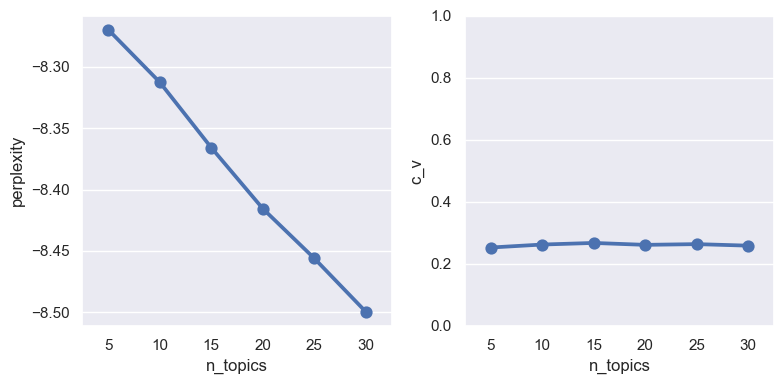

In [4]:
params = {
    "n_topics" : np.arange(5, 35, 5),
    "perplexity" : [],
    "c_v" : []
}

for k in params["n_topics"]:
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42, chunksize=100, per_word_topics=True)
    coherence_model = CoherenceModel(model=lda_model, texts=texts_tokens, dictionary=dictionary, coherence='c_v')
    params["perplexity"].append(lda_model.log_perplexity(corpus))
    c_v = coherence_model.get_coherence()
    params["c_v"].append(coherence_model.get_coherence())

df = pd.DataFrame(data=params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
sns.pointplot(data=df, x="n_topics", y="perplexity", ax=ax1)
sns.pointplot(data=df, x="n_topics", y="c_v", ax=ax2)
ax2.set_ylim(0, 1)
plt.tight_layout()

In [6]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=10, passes=10, random_state=42, chunksize=100, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

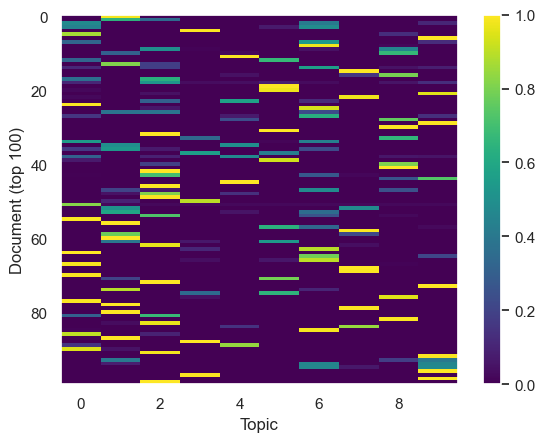

In [7]:
doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
                              for bow in corpus])

limit = 100
plt.imshow(doc_topic_matrix[:limit, :], aspect="auto", vmin=0, vmax=1, cmap="viridis")
plt.xlabel("Topic")
plt.ylabel(f"Document (top {limit})")
plt.colorbar()
plt.grid(False)

<Axes: ylabel='Count'>

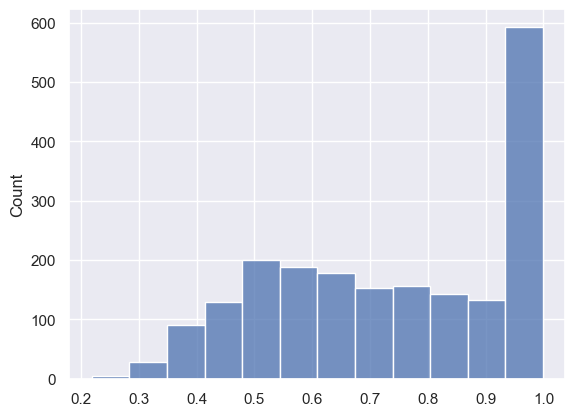

In [8]:
max_probas = doc_topic_matrix.max(axis=1)
sns.histplot(max_probas)

In [9]:
dominant_topics = doc_topic_matrix.argmax(axis=1)
umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
embedding = umap_.fit_transform(doc_topic_matrix)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


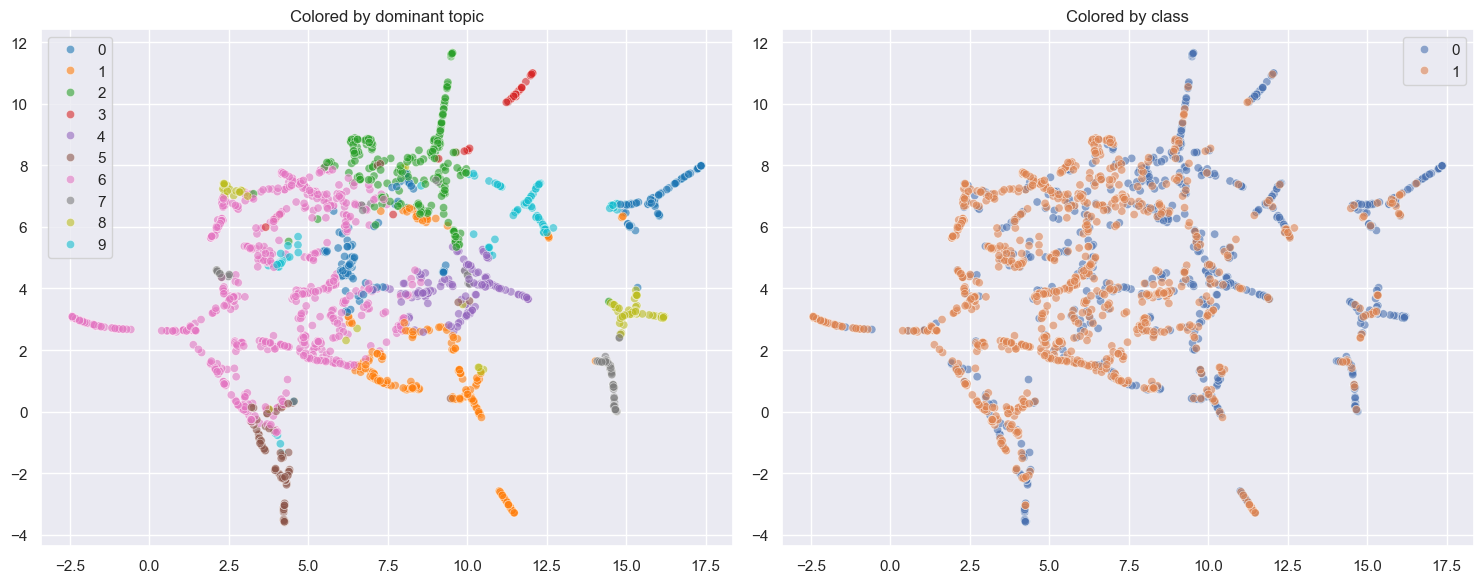

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.set_title("Colored by dominant topic")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=dominant_topics,
    palette="tab10",       
    alpha=0.6,
    ax=ax1
)
ax2.set_title("Colored by class")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=classes_movies,       
    alpha=0.6,
    ax=ax2
)

plt.tight_layout()

### Presidents

**Notes**

- LDA struggles with very short documents (the case here, since very likely the whole docs were cut into phrases). Indeed, if LDA (e.g. 5 topics) is examined on `texts_pres`, topics are hard to interpret. However, if LDA is run on `texts_pres_concat` (much longer documents), topics are much more meaningful

- **To test** : since for predictions topics would be inferred per phrase , check if performance is ok

In [13]:
texts_pres, classes_pres = load_clean_data("../Dataset/presidents_clean.parquet")
texts_pres_concat, classes_pres_concat = concat_seq_by_class(texts_pres, classes_pres, n=20)

#### LDA on `texts_pres`

LDA is supposed to struggle on very short documents (normal since LDA's hypothesis : each document is a mix of topics) -> the case here, most relevant terms are not explanatory 

In [15]:
texts_tokens = [text.split() for text in texts_pres]
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=5, no_above=0.40)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=10, random_state=42, chunksize=50, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

#### LDA on `texts_pres_concat`

Use LDA instead on concatenated phrases (with max fixed)

In [16]:
texts_tokens = [text.split() for text in texts_pres_concat]
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=5, no_above=0.40)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

5 0.3915168489783677
10 0.4189295646638097
15 0.42248236712437687
20 0.4381783105106078
25 0.401708471802985
30 0.3642114492823986


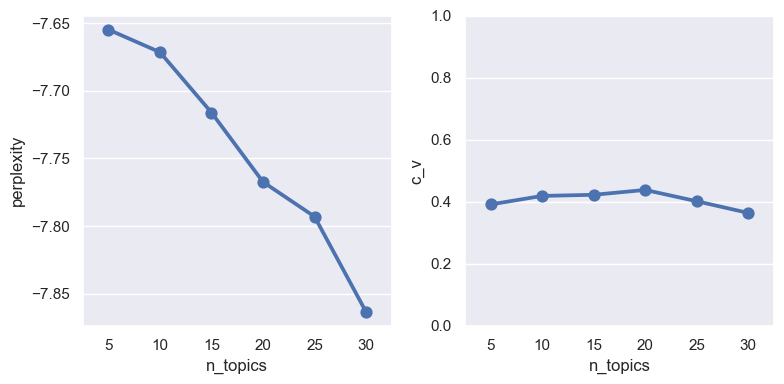

In [17]:
params = {
    "n_topics" : np.arange(5, 35, 5),
    "perplexity" : [],
    "c_v" : []
}

for k in params["n_topics"]:
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42, chunksize=100, per_word_topics=True)
    coherence_model = CoherenceModel(model=lda_model, texts=texts_tokens, dictionary=dictionary, coherence='c_v')
    params["perplexity"].append(lda_model.log_perplexity(corpus))
    c_v = coherence_model.get_coherence()
    params["c_v"].append(coherence_model.get_coherence())
    print(k, c_v)

df = pd.DataFrame(data=params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

sns.pointplot(data=df, x="n_topics", y="perplexity", ax=ax1)
sns.pointplot(data=df, x="n_topics", y="c_v", ax=ax2)
ax2.set_ylim(0, 1)

plt.tight_layout()

In [18]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=15, passes=20, random_state=42, chunksize=100, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

#### UMAP on concatenated phrases

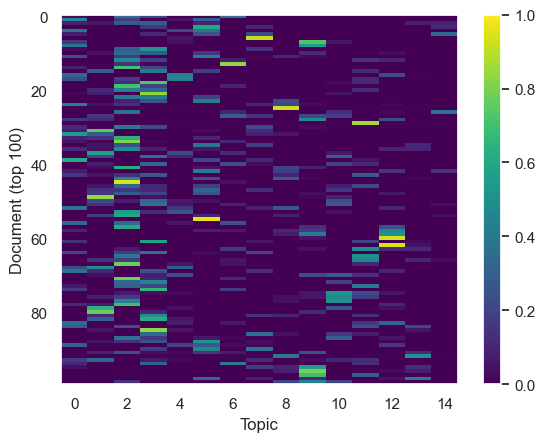

In [19]:
doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
                              for bow in corpus])

limit = 100
plt.imshow(doc_topic_matrix[:limit, :], aspect="auto", vmin=0, vmax=1, cmap="viridis")
plt.xlabel("Topic")
plt.ylabel(f"Document (top {limit})")
plt.colorbar()
plt.grid(False)

<Axes: ylabel='Count'>

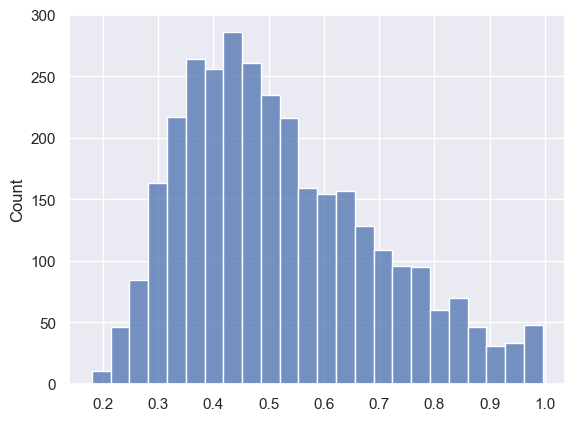

In [20]:
sns.histplot(doc_topic_matrix.max(axis=1))

In [ ]:
dominant_topics = doc_topic_matrix.argmax(axis=1)

umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
embedding = umap_.fit_transform(doc_topic_matrix)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


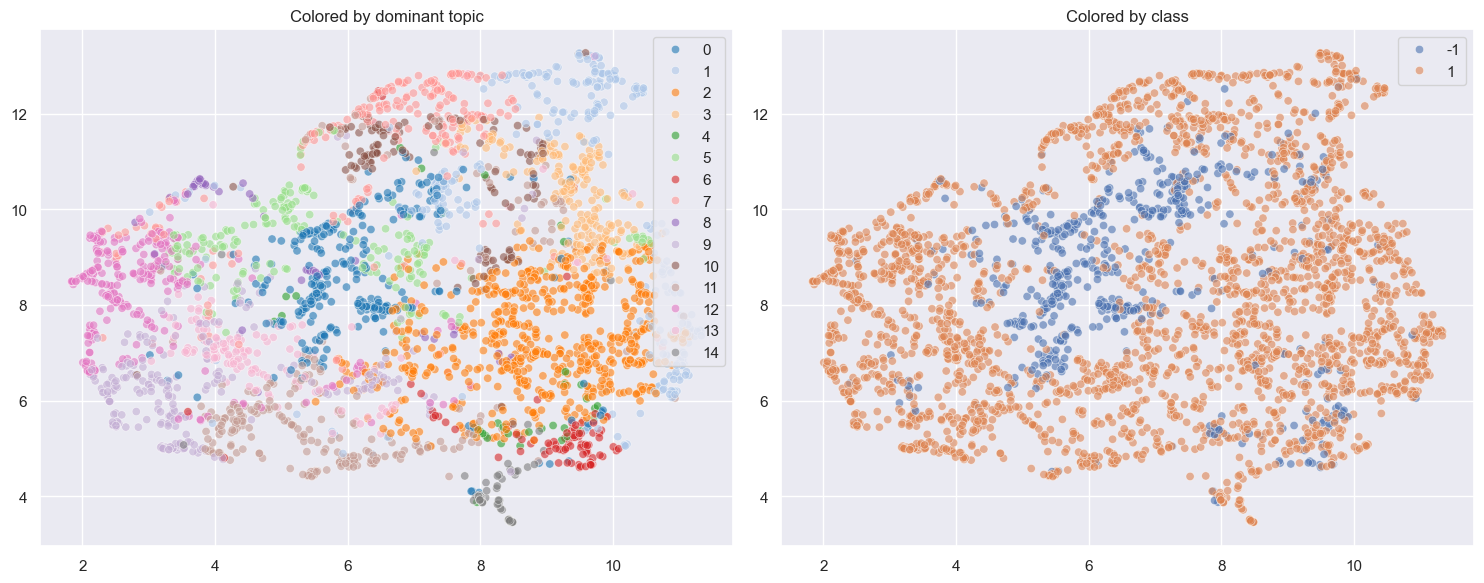

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.set_title("Colored by dominant topic")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=dominant_topics[:],
    palette="tab20",       
    alpha=0.6,
    ax=ax1
)
ax2.set_title("Colored by class")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=classes_pres_concat[:],    
    palette="deep",
    alpha=0.6,
    ax=ax2
)

plt.tight_layout()

##### UMAP on separated phrases


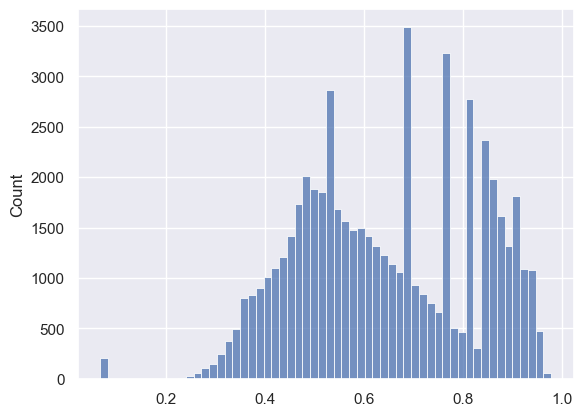

In [ ]:
# texts_tokens = [text.split() for text in texts_pres]
# corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]
# doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
#                               for bow in corpus])

# sns.histplot(doc_topic_matrix.max(axis=1))

# proba_max = doc_topic_matrix.max(axis=1)
# mask = proba_max > 0.9  # only keep documents with clear dominant topic (to reduce 50k points to 10k)
# subset = doc_topic_matrix[mask]
# dominant_topics = subset.argmax(axis=1)

In [ ]:
# # RuntimeWarning :invalid value encountered in correct_alternative_hellinger
# # -> a known upstream issue in UMAP's Hellinger implementation with numba (not fully fixed yet)

# umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
# embedding = umap_.fit_transform(subset)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: invalid value encountered in correct_alternative_hellinger
  return super().__call__(*args, **kws)


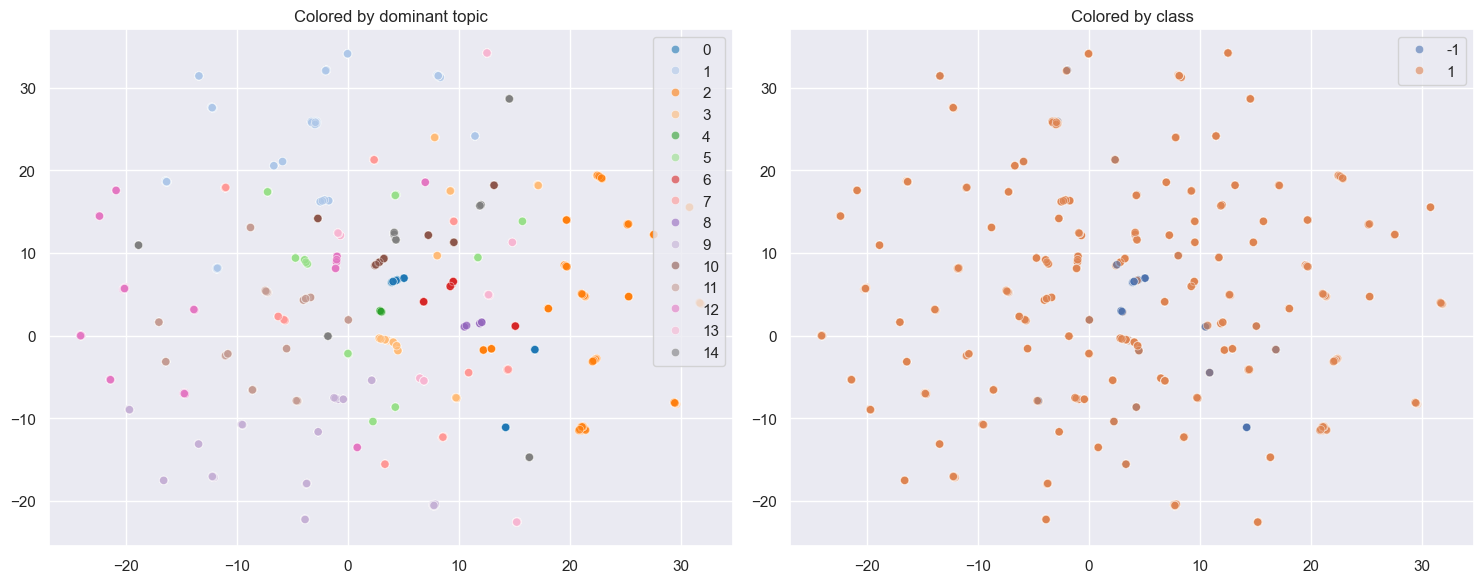

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ax1.set_title("Colored by dominant topic")
# sns.scatterplot(
#     x=embedding[:, 0],
#     y=embedding[:, 1],
#     hue=dominant_topics,
#     palette="tab20",       
#     alpha=0.6,
#     ax=ax1
# )
# ax2.set_title("Colored by class")
# sns.scatterplot(
#     x=embedding[:, 0],
#     y=embedding[:, 1],
#     hue=classes_pres[mask],    
#     palette="deep",
#     alpha=0.6,
#     ax=ax2
# )

# plt.tight_layout()